<a href="https://colab.research.google.com/github/ada06052005/Analytical_Study_of_Water_Pollution_Across_Multiple_Water_Bodies/blob/main/Pond.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df=pd.read_csv("/content/pond.csv")
df

,Type Water Body,State Name,Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform),Year,WQI
0,POND,ASSAM,4.30,7.15,104.5,2.60,0.90,1300.0,2022,51
1,POND,ASSAM,7.25,7.05,97.5,2.35,1.45,1205.0,2022,68
2,POND,ASSAM,8.35,7.60,263.5,2.40,1.40,1455.0,2022,78
3,POND,ASSAM,6.35,7.15,99.5,2.35,1.05,930.0,2022,61
4,POND,ASSAM,6.25,7.10,74.0,2.45,1.00,1060.0,2022,61
...,...,...,...,...,...,...,...,...,...,...
511,POND,TRIPURA,8.20,7.10,173.5,2.30,0.60,335.0,2018,67
512,POND,TRIPURA,7.50,7.45,142.0,1.25,0.40,250.0,2018,63
513,POND,TRIPURA,6.95,7.05,133.0,1.20,0.60,285.0,2018,59
514,POND,UTTAR \nPRADESH,6.05,8.30,2298.5,52.75,4.10,58000.0,2018,517


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 516 entries, 0 to 515
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Type Water Body       516 non-null    object 
 1   State Name            516 non-null    object 
 2   Mean (DO)             516 non-null    float64
 3   Mean(pH)              516 non-null    float64
 4   Mean conductivity)    516 non-null    float64
 5   Mean(BOD)             516 non-null    float64
 6   Mean Nitrite)         516 non-null    float64
 7   Mean(total coliform)  516 non-null    float64
 8   Year                  516 non-null    int64  
 9   WQI                   516 non-null    int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 40.4+ KB


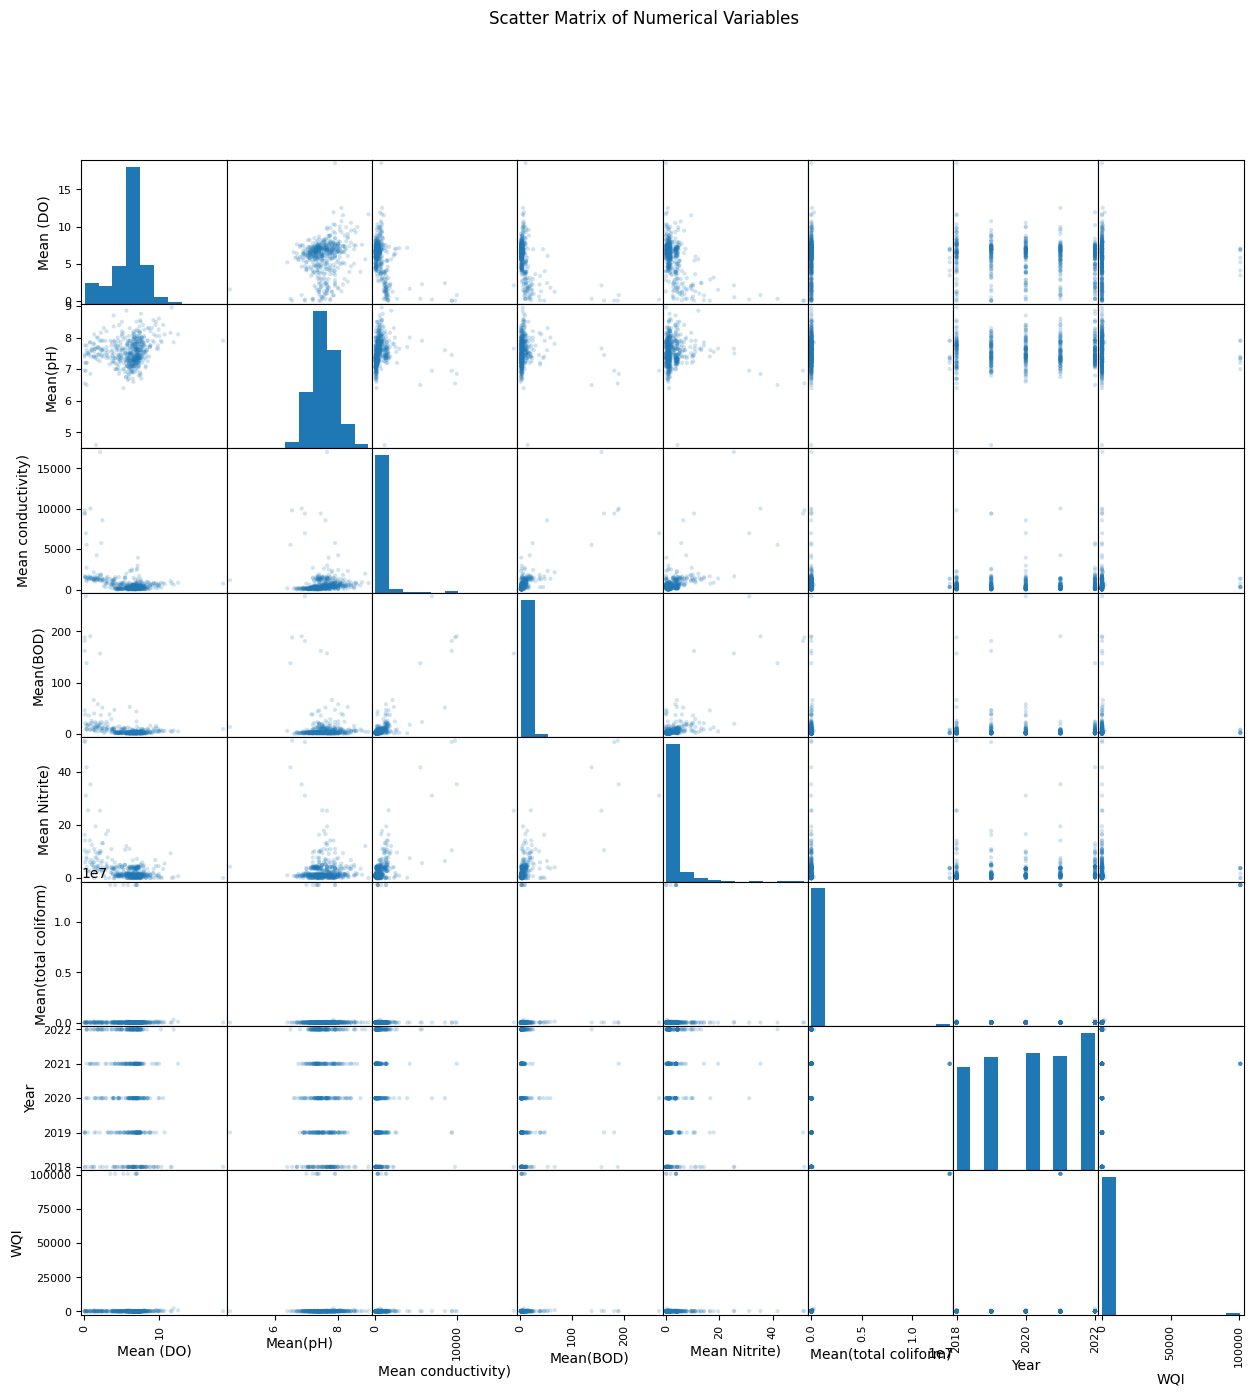

,Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform),Year,WQI
count,516.000000,516.000000,516.000000,516.000000,516.000000,5.160000e+02,516.000000,516.000000
mean,5.976224,7.535895,668.717859,8.032984,2.840649,2.173892e+05,2020.118217,1657.912791
std,2.252645,0.412666,1326.405300,22.529822,5.074225,1.692804e+06,1.422284,12458.631987
min,0.050000,4.600000,25.500000,0.450000,0.000000,2.000000e+00,2018.000000,31.000000
25%,5.000000,7.300000,151.250000,2.000000,0.838750,1.637500e+02,2019.000000,57.000000
50%,6.500000,7.500000,347.500000,3.025000,1.300000,7.010000e+02,2020.000000,62.000000
75%,7.212500,7.800000,719.000000,5.812500,3.565000,2.135250e+03,2021.000000,77.000000
max,18.500000,8.950000,17025.000000,268.500000,51.800000,1.369291e+07,2022.000000,100839.000000


In [ ]:
import matplotlib.pyplot as plt

# Summarize numerical data to review key statistics
numerical_summary = df.describe()

# Plot pairwise relationships to check for linear trends with the target variable (WQI)
pd.plotting.scatter_matrix(df.select_dtypes(include=['float64', 'int64']), alpha=0.2, figsize=(15, 15), diagonal='hist')
plt.suptitle("Scatter Matrix of Numerical Variables")
plt.show()

numerical_summary

In [ ]:
from sklearn.preprocessing import StandardScaler

# Selecting numerical predictors and the target variable
predictor_columns = [ 'Mean (DO)', 'Mean(pH)', 'Mean conductivity)',
                     'Mean(BOD)', 'Mean Nitrite)', 'Mean(total coliform)']
target_column = 'WQI'

# Extract predictors and target
X = df[predictor_columns]
y = df[target_column]

# Scaling predictors
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled predictors back to a DataFrame for readability
X_scaled_df = pd.DataFrame(X_scaled, columns=predictor_columns)

# Display first few rows of scaled data
X_scaled_df.head()


,Mean (DO),Mean(pH),Mean conductivity),Mean(BOD),Mean Nitrite),Mean(total coliform)
0,-0.744836,-0.936035,-0.425786,-0.241380,-0.382823,-0.127776
1,0.566007,-1.178597,-0.431069,-0.252488,-0.274327,-0.127832
2,1.054796,0.155493,-0.305797,-0.250266,-0.284191,-0.127684
3,0.166089,-0.936035,-0.429560,-0.252488,-0.353234,-0.127994
4,0.121653,-1.057316,-0.448803,-0.248045,-0.363097,-0.127917


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Calculate VIF for each predictor
vif_data = pd.DataFrame()
vif_data["Variable"] = predictor_columns
vif_data["VIF"] = [variance_inflation_factor(X_scaled, i) for i in range(X_scaled.shape[1])]

vif_data


,Variable,VIF
0,Mean (DO),1.403475
1,Mean(pH),1.089910
2,Mean conductivity),3.361322
3,Mean(BOD),4.072548
4,Mean Nitrite),2.787776
5,Mean(total coliform),1.002773


In [ ]:
# Calculate skewness for each predictor and the target variable
skewness = df[predictor_columns + [target_column]].skew()

# Select variables with high skewness (absolute skewness > 1)
high_skew_vars = skewness[abs(skewness) > 1].index.tolist()
skewness


,0
Mean (DO),-0.445043
Mean(pH),-0.352395
Mean conductivity),7.025913
Mean(BOD),7.630993
Mean Nitrite),5.880018
Mean(total coliform),7.864588
WQI,7.864498


In [ ]:
# Apply log transformation to highly skewed variables (adding 1 to avoid log(0))
transformed_df = df.copy()
for col in high_skew_vars:
    transformed_df[col] = np.log1p(transformed_df[col])

# Scale predictors after transformation
X_transformed = transformed_df[predictor_columns]
y_transformed = transformed_df[target_column]
X_scaled_transformed = scaler.fit_transform(X_transformed)

# Add constant for regression
X_transformed_const = sm.add_constant(X_scaled_transformed)

# Fit the regression model with transformed data
model_transformed = sm.OLS(y_transformed, X_transformed_const).fit()

# Summarize the transformed regression results
transformed_model_summary = model_transformed.summary()
transformed_model_summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    WQI   R-squared:                       0.675
Model:                            OLS   Adj. R-squared:                  0.672
Method:                 Least Squares   F-statistic:                     176.6
Date:                Fri, 29 Nov 2024   Prob (F-statistic):          6.28e-121
Time:                        07:36:40   Log-Likelihood:                -466.61
No. Observations:                 516   AIC:                             947.2
Df Residuals:                     509   BIC:                             977.0
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.4156      0.026    166.669      0.000       4.364       4.468
x1             0.2245      0.035      6.355      0.000       0.155       0.294
x2            -0.1144      0.031     -3.747      0.000      -0.174      -0.054
x3             0.2702      0.039      6.959      0.000       0.194       0.347
x4            -0.1096      0.041     -2.647      0.008      -0.191      -0.028
x5            -0.0162      0.036     -0.451      0.652      -0.087       0.054
x6             0.8428      0.028     30.098      0.000       0.788       0.898
==============================================================================
Omnibus:                      330.650   Durbin-Watson:                   1.122
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             3801.866
Skew:                           2.660   Prob(JB):                         0.00
Kurtosis:                      15.187   Cond. No.                         3.11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""